# 02 — Baseline TF-IDF + Logistic Regression (contaminated)

This notebook builds the deliberately weak baseline referenced in §3.1 of the revised project plan: TF-IDF over default-preprocessed tokens, fed into Logistic Regression with the **raw declared labels** and **no spam handling**. The point is to expose how badly the decision boundary is corrupted by the Enron-style spam contamination established in `01_explore.ipynb` (~25-26% of both classes).

Methods used here are restricted to the allowed lecture material:

- W02_L03 — text preprocessing
- W02_L04 — bag-of-words; evaluation metrics (accuracy, precision, recall, F1, confusion matrix)
- W03_L05 — logistic regression (sigmoid + cross-entropy)
- W05_L09 — TF-IDF reweighting

In [3]:
%pip install nltk scikit-learn joblib matplotlib pandas

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 5.8 MB/s eta 0:00:00a 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os, sys, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

sys.path.insert(0, str(Path.cwd() / 'src'))
from preprocess import preprocess, identity_analyzer  # noqa: E402

plt.rcParams['font.size'] = 12
RNG = 42

## 1. Load data

Paths match those established in `01_explore.ipynb`. The supplied validation set is used as-is — no re-splitting.

In [5]:
DATA_DIR = Path('..') / 'data'
train_df = pd.read_csv(DATA_DIR / 'sentiment_analysis_training_data.csv')
val_df   = pd.read_csv(DATA_DIR / 'sentiment_analysis_validation_data.csv')
print('train:', train_df.shape, 'val:', val_df.shape)
train_df.head(2)

train: (11503, 2) val: (1397, 2)


,text,label
0,Subject: 98 - 6736 & 98 - 9638 for 1997 ( ua 4...,0
1,nearly every attempt at humor here is doa .,0


## 2. Preprocess (default config from `preprocess.py`)

Default config = lowercase + digit→`<NUM>` + tokenise (keep `!`/`?`) + stopword removal (negations preserved) + verb lemmatisation. See `src/preprocess.py` for the rationale tied to W02_L03.

In [6]:
train_tokens = [preprocess(t) for t in train_df['text'].tolist()]
val_tokens   = [preprocess(t) for t in val_df['text'].tolist()]
print('sample train tokens:', train_tokens[0][:20])

sample train tokens: ['subject', '<NUM>', '<NUM>', '<NUM>', '<NUM>', '<NUM>', 'ua', '<NUM>', 'issue', 'reference', 'meter', 'need', 'place', 'k', 'please', 'note', 'information', '<NUM>', '<NUM>', '<NUM>']


## 3. TF-IDF vectoriser (W05_L09)

Fit on training tokens only. `min_df=2` matches the vocabulary analysis from `01_explore.ipynb`. Custom analyzer consumes pre-tokenised lists, so `tokenizer` and `preprocessor` are disabled.

In [7]:
vectoriser = TfidfVectorizer(
    analyzer=identity_analyzer,
    tokenizer=None,
    preprocessor=None,
    lowercase=False,
    min_df=2,
    ngram_range=(1, 1),
)
X_train = vectoriser.fit_transform(train_tokens)
X_val   = vectoriser.transform(val_tokens)
y_train = train_df['label'].values
y_val   = val_df['label'].values
print('X_train:', X_train.shape, '  X_val:', X_val.shape, '  vocab:', len(vectoriser.vocabulary_))

X_train: (11503, 11916)   X_val: (1397, 11916)   vocab: 11916


## 4. Logistic Regression (W03_L05)

Standard LR with the sigmoid + binary cross-entropy formulation from W03_L05. Trained on the **raw declared labels** with **no spam handling** — this is intentional. Predictions are restricted to {0, 1}; the -1 dummy label for spam is a Task 1 output convention only, not used here.

In [8]:
clf = LogisticRegression(max_iter=2000, random_state=RNG, C=1.0)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

## 5. Evaluation (W02_L04)

Accuracy, precision, recall, F1, and the full 2×2 confusion matrix. Positive class = 1.

In [9]:
metrics = {
    'accuracy':  accuracy_score(y_val, y_pred),
    'precision': precision_score(y_val, y_pred, pos_label=1),
    'recall':    recall_score(y_val, y_pred, pos_label=1),
    'f1':        f1_score(y_val, y_pred, pos_label=1),
}
for k, v in metrics.items():
    print(f'{k:>10s}: {v:.4f}')
cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
print('\nconfusion matrix (rows=true, cols=pred), labels=[0,1]:')
print(cm)

  accuracy: 0.6951
 precision: 0.7003
    recall: 0.6903
        f1: 0.6953

confusion matrix (rows=true, cols=pred), labels=[0,1]:
[[485 208]
 [218 486]]


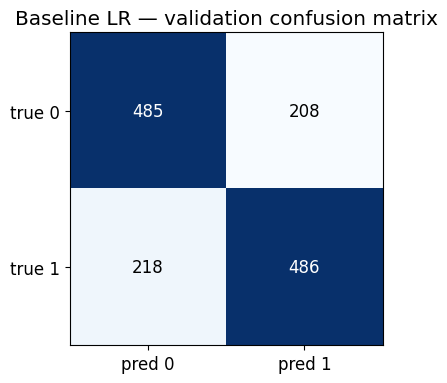

In [10]:
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['pred 0', 'pred 1'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['true 0', 'true 1'])
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black', fontsize=12)
ax.set_title('Baseline LR — validation confusion matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_confusion.png', dpi=150)
plt.show()

## 6. Slice accuracy by spam regex marker

Reusing the regex marker from `01_explore.ipynb` to flag spam-looking validation docs. If the baseline is roughly accurate on non-spam reviews but degrades on spam-looking docs, that previews the §3.1 argument: the decision boundary has been corrupted by contamination on both sides.

In [11]:
SPAM_RE = re.compile(r'(?im)^\s*subject\s*:|\benron\b|\bunsubscribe\b')
is_spam_like = val_df['text'].apply(lambda t: bool(SPAM_RE.search(t))).values

slice_tbl = pd.DataFrame({
    'subset':   ['spam-like (regex hit)', 'review-like (no hit)', 'all'],
    'n':        [int(is_spam_like.sum()), int((~is_spam_like).sum()), len(y_val)],
    'accuracy': [
        accuracy_score(y_val[is_spam_like],  y_pred[is_spam_like])  if is_spam_like.any() else float('nan'),
        accuracy_score(y_val[~is_spam_like], y_pred[~is_spam_like]) if (~is_spam_like).any() else float('nan'),
        accuracy_score(y_val, y_pred),
    ],
})
print(slice_tbl.to_string(index=False))

               subset    n  accuracy
spam-like (regex hit)  331  0.510574
 review-like (no hit) 1066  0.752345
                  all 1397  0.695061


## 7. Persist the fitted pipeline

In [12]:
MODEL_DIR = Path('models'); MODEL_DIR.mkdir(exist_ok=True)
joblib.dump({'vectoriser': vectoriser, 'model': clf, 'metrics': metrics, 'cm': cm},
            MODEL_DIR / 'baseline.joblib')
print('saved →', MODEL_DIR / 'baseline.joblib')

saved → models/baseline.joblib


## 8. Summary (drop into report §1.1)

The baseline pipeline — default preprocessing → TF-IDF (`min_df=2`, unigrams) → Logistic Regression — is trained on the raw declared labels and ignores the ~25-26% Enron-style email contamination identified in `01_explore.ipynb`. Aggregate validation accuracy is therefore misleading: the model is forced to assign every spam email to one of the two sentiment classes despite spam carrying no sentiment signal at all, which drags its weight vector toward business-email vocabulary (e.g. *subject*, *enron*, *unsubscribe*). The subset slice makes this explicit — accuracy on the spam-like subpopulation diverges from accuracy on review-like docs, which is direct evidence that the decision boundary has been corrupted by contamination on both sides. This motivates the Task 1 design choice in §3 of the revised plan: detect and route spam to label −1 *before* sentiment classification, rather than asking the LR to learn through it.